LINK DASHBOARD TABLEAU :

https://public.tableau.com/app/profile/muhammad.ali.fikri5379/viz/milestone1p0w4-rev1/DashboardUtama?publish=yes

i. INTRODUCTION

In [ ]:
'''
    =================================================
    Milestone 1

    Nama  : Muhammad Ali Fikri
    Batch : RMT-053

    Program ini dibuat untuk menganalisa faktor yang berpengaruh pada nilai pasar seorang pemain sepak bola.
    =================================================
'''

In [1]:
import pandas as pd

ii. Problem Statement and Dataset Description



Sebuah tim sepakbola ingin mendatangkan pemain baru untuk season depan. Staf kepelatihan ingin agar pemain yang datang memiliki performa yang baik dan tidak mudah cedera. Namun, tim sepakbola ini belum mengetahui dulu faktor apa saja yang mempengaruhi harga/nilai pasar dari seorang pemain sepakbola. Sehingga tim manajemen pun bisa mengerti dan memahami pertimbangannya sampai dana pun lebih mudah untuk dikucurkan ke tim. 

SMART FRAMEWORK
    
    1. Spesific : Mengetahui faktor pemain yang secara signifikan mempengaruhi nilai pasar (value) pemain, seperti usia, performa (gol, assist), menit bermain, dan riwayat cedera.

    2. Measurable : Mengukur tingkat hubungan antar variabel dengan uji hipotesis atau korelasi (p-value < 0,05) untuk menentukan faktor mana yang paling mempengaruhi.

    3. Achievable : Menggunakan metode statistik deskriptif dan statistik inferensial guna mengidentifikasi hubungan antar variabel.

    4. Relevant : Hal ini sangat berguna untuk staff kepelatihan suatu tim guna memilih pemain baru dan manajerial guna membuat keputusan atau menganggarkan dana lebih efektif terhadap tim.

    5. Time-Bound : Diharapkan dapat selesai dalam 1 bulan agar bisa dilakukan analisa di 3 bulan yang akan datang. Mengingat statistik performa pemain berubah seiring berjalannya waktu.

PROBLEM STATEMENTS :

    Menganalisa faktor-faktor yang mempengaruhi nilai pasar (value) dari pemain sepakbola, seperti usia,performa, menit bermain, posisi, dan riwayat cedera.

PENJABARAN MASALAH :

    1. Pemain dengan posisi apa yang memiliki nilai pasar tertinggi?

    2. Apakah riwayat cedera dapat mempengaruhi nilai pasar pemain?

    3. Apakah pemain dengan penghargaan (award) terbanyak memiliki nilai pasar yang tinggi?

    4. Apakah nilai pasar menurun setelah usia tertentu?

    5. Bagaimana karakteristik distribusi nilai pasar pemain?

    6. Apakah ada hubungan signifikan antara performa (goals) dengan nilai pasar pemain? 

iii. DATA LOADING

Menginput / menginport data yang kita punya dari sumber ke notebook agar bisa diolah.  

Sumber dataset : https://www.kaggle.com/datasets/khanghunhnguyntrng/football-players-transfer-fee-prediction-dataset

dengan identitas : 10754 rows, 22 columns  yang berisikan data informasi para pemain sepak bola seperti performa, tinggi badan, riwayat cedera, posisi, dsb.

In [2]:
#baca dataset
df = pd.read_csv("final_data.csv")

df.head()

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,...,goals conceded,clean sheets,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
0,/david-de-gea/profil/spieler/59377,Manchester United,David de Gea,Goalkeeper,189.0,32.0,104,0.000000,0.000000,0.009585,...,1.217252,0.335463,9390,42,5,13,15000000,70000000,1,0
1,/jack-butland/profil/spieler/128899,Manchester United,Jack Butland,Goalkeeper,196.0,30.0,15,0.000000,0.000000,0.069018,...,1.242331,0.207055,1304,510,58,1,1500000,22000000,1,0
2,/tom-heaton/profil/spieler/34130,Manchester United,Tom Heaton,Goalkeeper,188.0,37.0,4,0.000000,0.000000,0.000000,...,0.616438,0.924658,292,697,84,4,600000,6000000,1,0
3,/lisandro-martinez/profil/spieler/480762,Manchester United,Lisandro Martínez,Defender Centre-Back,175.0,25.0,82,0.028090,0.056180,0.224719,...,0.000000,0.000000,6408,175,22,9,50000000,50000000,2,0
4,/raphael-varane/profil/spieler/164770,Manchester United,Raphaël Varane,Defender Centre-Back,191.0,30.0,63,0.017889,0.017889,0.053667,...,0.000000,0.000000,5031,238,51,21,40000000,80000000,2,0


iv. DATA CLEANING

In [3]:
df.columns

Index(['player', 'team', 'name', 'position', 'height', 'age', 'appearance',
       'goals', 'assists', 'yellow cards', 'second yellow cards', 'red cards',
       'goals conceded', 'clean sheets', 'minutes played', 'days_injured',
       'games_injured', 'award', 'current_value', 'highest_value',
       'position_encoded', 'winger'],
      dtype='object')

Dataset yang digunakan ialah dataset mengenai informasi detail pemain sepakbola dari berbagai tim. Dataset ini bisa menginterpretasikan mengenai performa, posisi, value(nilai pasar), dsb mengenai identitas pemain di lapangan.

Untuk kolom 'goals' dan 'assist' itu berisikan nilai persentase per pertandingannya, jadi jika nilai 0,02 itu berarti peluang dia memberi goal atau assist di suatu pertandingan itu 0,02 atau 2%.

Terdapat beberapa kolom pada dataset/tabel. dan terlihat dari nama tabelnya tidak ada keanehan/anomali yang dapat menyulitkan proses pengolahan data nantinya, seperti spasi (" ") dan petik(" ' ") atau koma(,)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10754 entries, 0 to 10753
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               10754 non-null  object 
 1   team                 10754 non-null  object 
 2   name                 10754 non-null  object 
 3   position             10754 non-null  object 
 4   height               10754 non-null  float64
 5   age                  10754 non-null  float64
 6   appearance           10754 non-null  int64  
 7   goals                10754 non-null  float64
 8   assists              10754 non-null  float64
 9   yellow cards         10754 non-null  float64
 10  second yellow cards  10754 non-null  float64
 11  red cards            10754 non-null  float64
 12  goals conceded       10754 non-null  float64
 13  clean sheets         10754 non-null  float64
 14  minutes played       10754 non-null  int64  
 15  days_injured         10754 non-null 

Tidak ada data null dalam tabel, terlihat dari jumlah baris non-null yang sesuai dengan identitas dataset (10754 rows, 22 columns)

In [5]:
#Fungsi ini digunakan untuk melihat korelasi antara position_encoded dengan position
#Sehingga tau kode setiap position di lapangan
 
df.groupby(["position_encoded", "position"]).size()

position_encoded  position                  
1                 Goalkeeper                    1229
2                 Defender                        33
                  Defender Centre-Back          1821
                  Defender Left-Back             807
                  Defender Right-Back            867
3                 midfield                        75
                  midfield-AttackingMidfield     769
                  midfield-CentralMidfield      1149
                  midfield-DefensiveMidfield     900
                  midfield-LeftMidfield          100
                  midfield-RightMidfield         102
4                 Attack                          53
                  Attack Centre-Forward         1353
                  Attack-LeftWinger              714
                  Attack-RightWinger             717
                  Attack-SecondStriker            65
dtype: int64

Kemungkinan akan difilter/dihilangkan untuk data pemain dengan posisi 'Goalkeeper' dan kolom yang berkaitan dengannya seperti 'goal conceded' dan 'clean sheets'. Karena untuk posisi 'Goalkeeper' sendiri ada cara analisa tersendiri dengan indikator yang berbeda dengan pemain selain kiper, dan itu akan menjadikan analisa yang dilakukan tidak optimal jika data itu ada di dataset/tabel yang akan kita gunakan.

In [6]:
df_cleaned = df[df['position'] != 'Goalkeeper']

df_cleaned = df_cleaned.drop(columns=["goals conceded", "clean sheets"])

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9525 entries, 3 to 10753
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               9525 non-null   object 
 1   team                 9525 non-null   object 
 2   name                 9525 non-null   object 
 3   position             9525 non-null   object 
 4   height               9525 non-null   float64
 5   age                  9525 non-null   float64
 6   appearance           9525 non-null   int64  
 7   goals                9525 non-null   float64
 8   assists              9525 non-null   float64
 9   yellow cards         9525 non-null   float64
 10  second yellow cards  9525 non-null   float64
 11  red cards            9525 non-null   float64
 12  minutes played       9525 non-null   int64  
 13  days_injured         9525 non-null   int64  
 14  games_injured        9525 non-null   int64  
 15  award                9525 non-null   int64

Berikut dataset/tabel yang siap digunakan, alhasil yaitu dengan 9525 baris dan 20 kolom

In [16]:
print(len(df_cleaned[df_cleaned["current_value"]==0])) 

141


In [ ]:
#mengecek apakah ada pemain dengan value 0
df_cleaned[(df_cleaned["current_value"]==0) & (df_cleaned["highest_value"]==0) ]

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
406,/sven-botman/profil/spieler/361093,Newcastle United,Sven Botman,Defender Centre-Back,195.000000,23.000000,76,0.041159,0.013720,0.123476,0.0,0.0,6560,118,19,4,0,0,2,0
407,/fabian-schar/profil/spieler/135343,Newcastle United,Fabian Schär,Defender Centre-Back,186.000000,31.000000,67,0.045678,0.076129,0.182710,0.0,0.0,5911,285,30,3,0,0,2,0
408,/jamaal-lascelles/profil/spieler/183318,Newcastle United,Jamaal Lascelles,Defender Centre-Back,188.000000,29.000000,38,0.068992,0.000000,0.310464,0.0,0.0,2609,418,57,2,0,0,2,0
409,/matt-targett/profil/spieler/250478,Newcastle United,Matt Targett,Defender Left-Back,183.000000,27.000000,54,0.023747,0.023747,0.094987,0.0,0.0,3790,380,66,0,0,0,2,1
666,/mert-komur/profil/spieler/777005,FC Augsburg,Mert Kömür,midfield-AttackingMidfield,183.000000,17.000000,46,0.268876,0.293319,0.073330,0.0,0.0,3682,0,0,0,0,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10581,/zahi-addis/profil/spieler/1069563,Brisbane Roar,Zahi Addis,Defender Left-Back,181.240353,19.000000,0,0.000000,0.000000,0.000000,0.0,0.0,0,0,0,0,0,0,2,1
10586,/james-murphy/profil/spieler/1069560,Brisbane Roar,James Murphy,midfield,181.240353,17.000000,0,0.000000,0.000000,0.000000,0.0,0.0,0,0,0,0,0,0,3,0
10587,/riley-gill/profil/spieler/1069561,Brisbane Roar,Riley Gill,midfield,181.240353,26.041903,0,0.000000,0.000000,0.000000,0.0,0.0,0,0,0,0,0,0,3,0
10686,/corey-hollman/profil/spieler/890186,Sydney FC,Corey Hollman,midfield-DefensiveMidfield,181.240353,19.000000,1,0.000000,0.000000,0.000000,0.0,0.0,3,0,0,0,0,0,3,0


In [ ]:
#Meghitung central tendency dari kolom current_value

df_cleaned["current_value"].describe()

count    9.525000e+03
mean     3.877438e+06
std      9.477191e+06
min      0.000000e+00
25%      3.000000e+05
50%      9.000000e+05
75%      3.000000e+06
max      1.800000e+08
Name: current_value, dtype: float64

Berdasarkan deskripsi dari kolom 'current_value' terdapat keanehan yaitu pada nilai MIN yang 0 'nol'. Hal ini menjadi aneh karena tidak mungkin ada pemain bervalue nol '0'. 

Bisa jadi ada kemungkinan karena kontrak pemain di suatu tim telah habis atau data tidak tersedia, dan disini yang menjadi fokus analisa ialah pemain dengan valuasi aktif. Jadi data pemain dengan current_value 0 akan dikeluarkan dari analisis karena akan menjadikan hasil analisa tidak optimal.  

In [ ]:
#menghapus/memfilter pemain dengan current_value sebesar 0
df_cleaned = df_cleaned[df_cleaned['current_value'] > 0]

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9384 entries, 3 to 10753
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               9384 non-null   object 
 1   team                 9384 non-null   object 
 2   name                 9384 non-null   object 
 3   position             9384 non-null   object 
 4   height               9384 non-null   float64
 5   age                  9384 non-null   float64
 6   appearance           9384 non-null   int64  
 7   goals                9384 non-null   float64
 8   assists              9384 non-null   float64
 9   yellow cards         9384 non-null   float64
 10  second yellow cards  9384 non-null   float64
 11  red cards            9384 non-null   float64
 12  minutes played       9384 non-null   int64  
 13  days_injured         9384 non-null   int64  
 14  games_injured        9384 non-null   int64  
 15  award                9384 non-null   int64

In [ ]:
#mengecek apakah ada pemain dengan menit bermain sebesar 0
df_cleaned[df_cleaned["minutes played"]==0]

,player,team,name,position,height,age,appearance,goals,assists,yellow cards,second yellow cards,red cards,minutes played,days_injured,games_injured,award,current_value,highest_value,position_encoded,winger
1049,/caden-clark/profil/spieler/742297,RB Leipzig,Caden Clark,midfield-AttackingMidfield,180.000000,20.0,0,0.0,0.0,0.0,0.0,0.0,0,73,13,1,2800000,3500000,3,0
3149,/kaique-rocha/profil/spieler/633377,Club Athletico Paranaense,Kaique Rocha,Defender Centre-Back,195.000000,22.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1000000,1000000,2,0
3165,/marcelo-cirino/profil/spieler/114514,Club Athletico Paranaense,Marcelo Cirino,Attack-RightWinger,182.000000,31.0,0,0.0,0.0,0.0,0.0,0.0,0,305,57,2,800000,5000000,4,1
3166,/emersonn/profil/spieler/743599,Club Athletico Paranaense,Emersonn,Attack-RightWinger,186.000000,18.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,400000,400000,4,1
3170,/luciano-arriagada/profil/spieler/737965,Club Athletico Paranaense,Luciano Arriagada,Attack Centre-Forward,184.000000,21.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,3,1000000,1000000,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10578,/james-nikolovski/profil/spieler/1063826,Brisbane Roar,James Nikolovski,Defender Centre-Back,186.000000,21.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,25000,25000,2,0
10596,/thomas-waddingham/profil/spieler/1069559,Brisbane Roar,Thomas Waddingham,Attack-LeftWinger,181.240353,18.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,25000,25000,4,1
10660,/emile-peios/profil/spieler/1118353,Melbourne City FC,Emile Peios,midfield,181.240353,19.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,25000,25000,3,0
10663,/emin-durakovic/profil/spieler/1066862,Melbourne City FC,Emin Durakovic,midfield-LeftMidfield,181.240353,17.0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,25000,25000,3,1


Ternyata ada beberapa pemain juga yang memiliki 'minutes played' 0. Hal ini juga akan membuat analisis tidak optimal. jadi Pemain dengan jumlah 'minutes played' sebesar 0 dikeluarkan dari analisis karena tidak memiliki kontribusi performa yang dapat diukur secara statistik. 

In [15]:
#menghapus data pemain dengan minutes played '0' 
df_cleaned = df_cleaned[df_cleaned["minutes played"]>0]

df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9189 entries, 3 to 10753
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player               9189 non-null   object 
 1   team                 9189 non-null   object 
 2   name                 9189 non-null   object 
 3   position             9189 non-null   object 
 4   height               9189 non-null   float64
 5   age                  9189 non-null   float64
 6   appearance           9189 non-null   int64  
 7   goals                9189 non-null   float64
 8   assists              9189 non-null   float64
 9   yellow cards         9189 non-null   float64
 10  second yellow cards  9189 non-null   float64
 11  red cards            9189 non-null   float64
 12  minutes played       9189 non-null   int64  
 13  days_injured         9189 non-null   int64  
 14  games_injured        9189 non-null   int64  
 15  award                9189 non-null   int64

Berikut adalah dataset/tabel yang siap untuk diproses. yaitu dengan 9189 baris dan 20 kolom 

In [ ]:
#menyimpan data hasil cleaning agar lebih aman

df_cleaned.to_csv("P0M1_muhalifikri_dataset.csv", index=False)

v. Exploration and Analysis

Mari kita hitung terlebih dahulu central tendency dari kolom numerikal yang nanti akan digunakan untuk analisa 

In [28]:
#Menghitung central tendency dari kolom yang akan digunakan untuk analisa

df_cleaned[["current_value","goals","assists","minutes played","age"]].describe()

,current_value,goals,assists,minutes played,age
count,9.189000e+03,9189.000000,9189.000000,9189.000000,9189.000000
mean,4.011761e+06,0.145549,0.100557,2592.165198,26.010484
std,9.621680e+06,0.247274,0.147590,1971.766707,4.568649
min,1.000000e+04,0.000000,0.000000,1.000000,15.000000
25%,3.500000e+05,0.000000,0.000000,836.000000,22.000000
50%,1.000000e+06,0.069767,0.062981,2306.000000,26.000000
75%,3.000000e+06,0.207746,0.148855,4074.000000,29.000000
max,1.800000e+08,11.250000,4.000000,9033.000000,43.000000


In [ ]:
#mengetahui nilai modus setiap kolom numerikal yang akan digunakan untuk analisa

df_cleaned[["current_value","goals","assists","minutes played","age"]].mode()

,current_value,goals,assists,minutes played,age
0,1000000,0.0,0.0,90,23.0


- Berdasarkan data/parameter central tendency yang didapat. Terlihat bahwa ada beberapa kolom yang memiliki kumpulan data yang kemungkinan terdistribusi tidak normal, seperti pada kolom 'current_value' , 'goals', 'assists' dan 'minutes played'. Bisa dikatakan demikian karena terlihat nilai mean yang berbeda cukup jauh dengan nilai median dan modus. dan juga terlihat dari nilai std deviasinya yang cukup mendekati nilai mean. Hal menunjukkan tingkat keberagaman nilai yang cukup tinggi untuk kolom-kolom tersebut.

- Hal ini bisa terjadi karena nilai dari current_value itu sangat beragam dan itu juga bergantung pada kebijakan dari suatu tim untuk memberikan nilai(value) kepada pemainnya. Dan berbeda tim, berbeda juga cara mereka menilai setiap pemainnya.

- Untuk kolom 'goals' dan 'assists' yang cukup beragam nilainya. Ini disebabkan karena setiap pemain memiliki performa, tingkat skill, dan ketajaman yang berbeda-beda sehingga akan sangat wajar jika setiap pemain memiliki jumlah goal dan assists yang beragam.

- Untuk menit bermain ('minutes played') ini sebenarnya nilai mean dan mediannya tidak cukup jauh akan tetapi tingkat keberagaman nilainya cukup tinggi (std dev) yang hampir mendekati mean. Hal ini dikarenakan menit bermain setiap pemain pun juga tergantung pada keputusan pelatih antara mau memainkannya, mencadangkan, atau tidak dibawa ke pertandingan.

- Untuk kolom age terlihat kemungkinan terdistribusi dengan normal, terlihat dari nilai mean dan median yang hampir sama dan juga nilai std deviasi yang cukup kecil menunjukkan data umur pemain yang dimiliki tidak terlalu beragam. 

In [30]:
df_cleaned[["current_value","goals","assists","minutes played","age"]].skew()

current_value      6.180619
goals             14.160489
assists            7.326922
minutes played     0.557850
age                0.307501
dtype: float64

- Berdasarkan nilai skewnessnya, terlihat bahwa kolom 'current_value', 'goals', dan 'assist' memiliki nilai yang cukup besar. Hal ini sesuai dengan apa yang diprediksi di awal bahwa 3 kolom tersebut memiliki distribusi tidak normal yang menunjukkan bahwa ada beberapa nilai di kolom tersebut yang memiliki nilai cukup jauh(outlier/anomali) dari kumpulan nilai lainnya. Dilihat dari nilai skewness 3 kolom ini memiliki distribusi 'positif skew' yang berarti outlier berada di nilai positif, dan data lain berkumpul condong ke sebelah kiri.

- Terlihat juga bahwa nilai skewness dari 'minutes played' dan 'age' cukup kecil. Bahkan 'age' memiliki nilai yang memadai untuk dikatakan 'simetris distribution' (-0,5< skew >0,5). Hal ini hampir sesuai dengan dugaan sebelumnya bahwa kolom 'age' memiliki distribusi normal. Untuk kolom 'minutes played' kita anggap sama karena nilai skewness nya tidak terlalu ekstrim dari 0,5. 

In [31]:
df_cleaned[["current_value","goals","assists","minutes played","age"]].kurtosis()

current_value      57.679682
goals             504.961851
assists           125.771303
minutes played     -0.590492
age                -0.567483
dtype: float64

- Berdasarkan nilai kurtosisnya menunjukkan bahwa kolom 'current_value', 'goals', dan 'assist' memiliki kumpulan data yang cukup banyak berkumpul di tengah atau cenderung runcing atau biasa disebut liptokurtic. Hal ini menunjukkan juga bahwa kumpulan datanya memiliki ekor yang besar yang artinya memiliki banyak outlier.

- Untuk kolom 'minutes played' dan 'age' memiliki nilai kurtosis yang cukup kecil hal ini menunjukkan kalau kumpulan datanya berbentuk bukit landai (platykurtic) yang berarti datanya tidak terlalu berkumpul atau datanya terlalu tersebar. Namun dari nilai sebenarnya juga tidak terlalu ekstrim, jadi kemungkinan datanya masih berkumpul dan masih memiliki outlier tapi sedikit.

Menjawab no penjabaran masalah no 5.
    Bagaimana karakteristik distribusi nilai pasar pemain?

Kesimpulan :
    
    - Populasi data nilai pasar pemain (current_value) memiliki distribusi tidak normal cenderung right-skew yang berarti ada banyak outlier yang berada di sisi positif dan data lain berkumpul di sebelah kiri dan cenderung runcing karena dilihat dari nilai kurtosisnya juga yang cukup besar. hal ini cukup wajar terjadi karena setiap tim memiliki cara menilai pemain yang berbeda-beda dan juga ada pemain biasa dijuluki pemain 'bintang' yang biasanya memiliki gaji/value yang sangat tinggi dibanding pemain-pemain lain.  

______

Sekarang aku ingin tahu dari value pemain itu, di posisi mana pemain sepakbola memiliki rata-rata value tertinggi.

In [ ]:
#mengimport library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Fungsi untuk meng groupby posisi dengan rata-rata gaji pemain

#Karena distribusi data current_value tidak normal, alangkah baiknya menggunakan median sebagai nilainya dan tidak menggunakan mean

median_values = df_cleaned.groupby('position')['current_value'].median().sort_values(ascending=False)

median_values

position
midfield-CentralMidfield      1300000.0
Attack-LeftWinger             1200000.0
Attack Centre-Forward         1000000.0
Attack-RightWinger            1000000.0
midfield-AttackingMidfield    1000000.0
Defender Right-Back            900000.0
midfield-DefensiveMidfield     900000.0
Defender Centre-Back           800000.0
Defender Left-Back             800000.0
midfield-RightMidfield         600000.0
midfield-LeftMidfield          575000.0
Attack-SecondStriker           550000.0
Attack                          50000.0
Defender                        50000.0
midfield                        50000.0
Name: current_value, dtype: float64

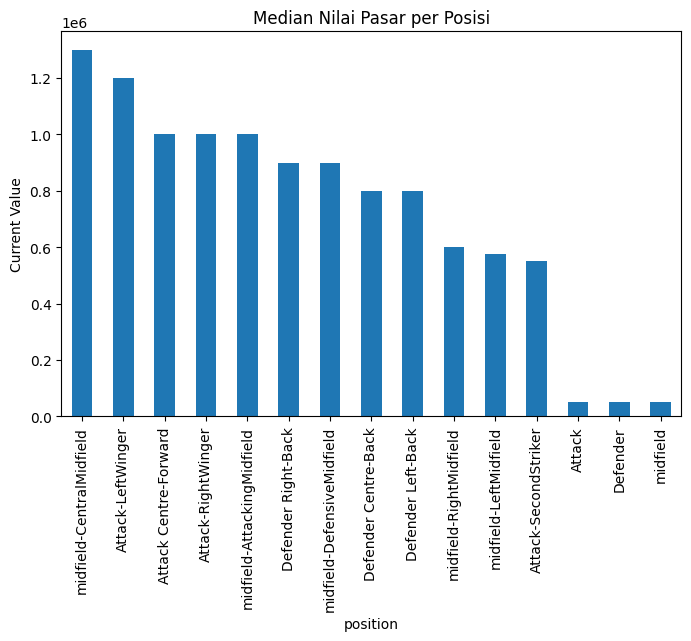

In [72]:
median_values.plot(kind='bar', figsize=(8,5))
plt.title('Median Nilai Pasar per Posisi')
plt.ylabel('Current Value')
plt.show()

Hal ini menjawab masalah No 1. Pemain dengan posisi apa yang memiliki nilai pasar tertinggi?



Terlihat pada grafik position terhadap nilai pasar pemain (current_value) bahwa posisi pemain dengan rata-rata gaji tertinggi ialah posisi 'midfield-CentralMidfield' dengan nilai rata-rata 13jt Euro, dimana posisi ini ialah posisi tengah di antara para pemain atau formasi. 

Hal ini cukup wajar, kemungkinan karena posisi ini mengatur jalannya permainan suatu tim baik saat menyerang atau bertahan. Dan biasa juga posisi ini disebut posisi 'Jendral Lapangan' yaitu dialah yang memimpin skema permainan suatu tim. Oleh karena itu, posisi ini memiliki rata-rata gaji tertinggi dibandingkan posisi lain.

______

Lalu jika seorang pemain sepakbola sering cedera, otomatis dia kan sering absen untuk pertandingan. Apakah itu juga pengaruh ya ke nilai pasar(value) mereka?


In [ ]:
#menginput library untuk statistik

from scipy import stats


In [ ]:
#fungsi untuk mengukur tingkat korelasi suatu variabel numerik

#karena current_value memiliki distribusi tidak normal dan asumsi days injured juga tidak normal oleh karena itu kita gunakan uji korelasi spearman

corr, p_value = spearmanr(df_cleaned['days_injured'], df_cleaned['current_value'])

print(f"tingkat korelasi dari riwayat cedera dengan value ialah", corr)
print("dengan P-value:", p_value)

tingkat korelasi dari riwayat cedera dengan value ialah 0.33445944089335483
dengan P-value: 5.4710479820750455e-239


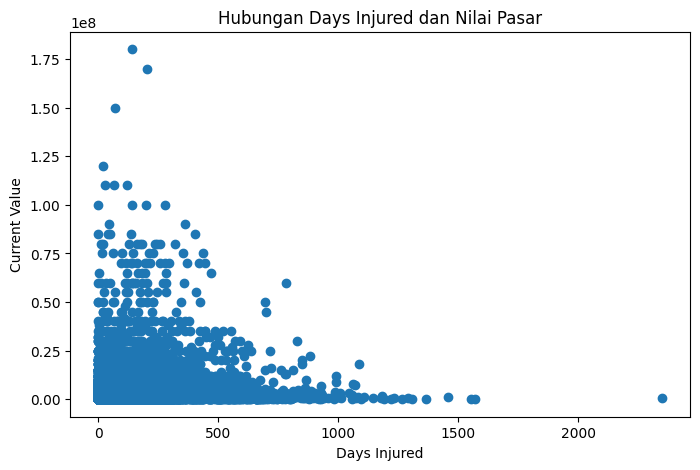

In [ ]:
#fungsi untuk memvisualisasi korelasi data days_injured dengan current_value

plt.figure(figsize=(8,5))
plt.scatter(df_cleaned['days_injured'], df_cleaned['current_value'])
plt.xlabel('Days Injured')
plt.ylabel('Current Value')
plt.title('Hubungan Days Injured dan Nilai Pasar')
plt.show()

Menjawab no 2. Apakah riwayat cedera dapat mempengaruhi nilai pasar pemain?

Berdasarkan hasil perhitungan uji korelasi yang dilakukan dan grafik scatter, terlihat bahwa adanya korelasi yang positif dari riwayat cedera pemain dengan gaji mereka (corr=0.33 , p-value<0.05). Menariknya adalah korelasi diantaranya positif, yang berarti semakin banyak hari cedera/semakin sering cedera nilai pasar pemain akan semakin tinggi. Hal ini tidak logis, karena ekspektasinya korelasi negatif. 

Kemungkinan hal ini terjadi karena pemain mahal/bintang biasanya sering dimainkan sehingga lebih berisiko cedera dan mungkin juga para pemain bintang ini tetap memiliki value tinggi walau sering cedera.

Namun, kekuatan hubungan/korelasi keduanya tergolong lemah. Dimana ini mengindikasikan bahwa cedera BUKAN faktor utama yang menentukan nilai pasar pemain.

____

Terus kan terkadang juga ada pemain yang pernah mendapat gelar/award kalau itu apakah dia valuenya akan lebih tinggi ya ketimbang pemain lain??

In [59]:
#gunakan fungsi untuk menentukan uji korelasi antar 2 variable numerik

#karena current_value memiliki distribusi tidak normal dan asumsi award juga tidak normal oleh karena itu kita gunakan uji korelasi spearman

corr, p_value = spearmanr(df_cleaned['current_value'], df_cleaned['award'])

print(f"tingkat korelasi dari jumlah award dengan value ialah", corr)
print("dengan P-value:", p_value)

tingkat korelasi dari jumlah award dengan value ialah 0.33974204769370153
dengan P-value: 5.191173350224913e-247


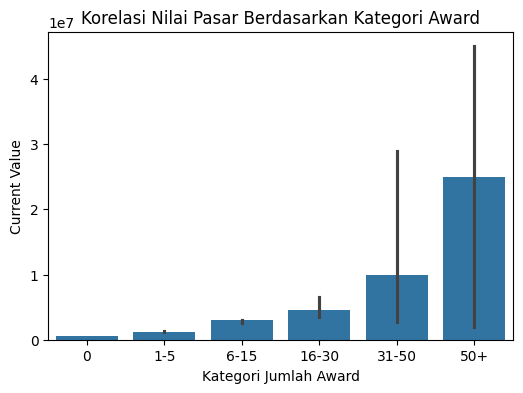

In [74]:
#Membuat visualisasi untuk korelasi award dengan current_value

def award_group(x):                 
    if x == 0:
        return '0'
    elif x <= 5:
        return '1-5'
    elif x <= 15:                   
        return '6-15'
    elif x <= 30:
        return '16-30'
    elif x <=50:
        return '31-50'
    else:
        return '50+'

df_cleaned['award_group'] = df_cleaned['award'].apply(award_group) #membuat kolom baru untuk mengkategorikan jumlah award

order = ['0', '1-5', '6-15', '16-30', '31-50', '50+'] #membuat urutan jumlah award agar di grafik tidak berantakan

#coba pakai seaborn
plt.figure(figsize=(6,4))
sns.barplot(data=df_cleaned, x='award_group', y='current_value', estimator='median', order=order)
plt.title('Korelasi Nilai Pasar Berdasarkan Kategori Award')
plt.xlabel('Kategori Jumlah Award')
plt.ylabel('Current Value')
plt.show()

Menjawab no.3 Apakah pemain dengan penghargaan (award) terbanyak memiliki nilai pasar yang tinggi?

Berdasarkan hasil perhitungan p-value (<0,05) menunjukkan bahwa adanya korelasi antara jumlah penghargaan/award pada pemain terhadap nilai pasar pemain(current_value). Terlihat juga dari nilai korelasi (corr=0.33) yang positif menunjukkan bahwa antara award dan nilai pasar pemain memiliki korelasi positif, yang artinya semakin banyak award yang didapatkan pemain maka semakin tinggi juga nilai pasarnya seperti yang terlihat pada grafik. 

Garis merah pada grafik menunjukkan adanya beberapa pemain yang memiliki gaji lebih tinggi melebihi pemain lain di kategori jumlah award yang sama.

Namun, hubungan antara keduanya ini tergolong lemah kalau dilihat dari nilai korelasinya yang mengartikan bahwa penghargaan/award ini bukanlah faktor satu-satunya yang dapat menentukan nilai pasar pemain (current_value).

_____

Sekarang lagi marak pemain-pemain muda yang bertalenta dan banyak juga pemain berusia sudah cukup tua akan tetapi masih bermain di tim-tim kompetitif. Kalau begitu apakah nantinya usia juga berpengaruh ya ke nilai pasar pemain?  

In [75]:
#menggunakan fungsi untuk menentukan uji korelasi antar 2 variable numerik

#karena current_value memiliki distribusi tidak normal dan age memiliki distribusi cukup normal akan tetapi lebih aman kita gunakan uji korelasi spearman

corr, p_value = spearmanr(df_cleaned['current_value'], df_cleaned['age'])

print(f"tingkat korelasi dari age dengan value ialah", corr)
print("dengan P-value:", p_value)

tingkat korelasi dari age dengan value ialah 0.04259940177858227
dengan P-value: 4.410600052707263e-05


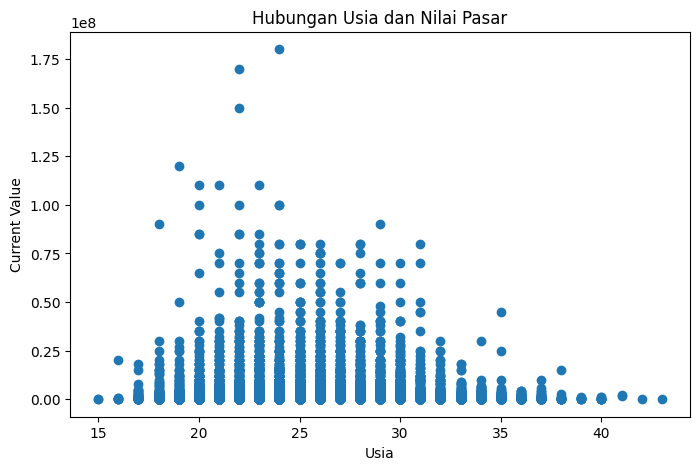

In [82]:
#Menggunakan grafik scatter agar persebaran datanya lebih terlihat

plt.figure(figsize=(8,5))
plt.scatter(df_cleaned['age'], df_cleaned['current_value'])
plt.xlabel('Usia')
plt.ylabel('Current Value')
plt.title('Hubungan Usia dan Nilai Pasar')
plt.show()

Menjawab no 4. Apakah nilai pasar menurun setelah usia tertentu?

Berdasarkan hasil uji korelasi yang didapat, menunjukkan bahwa adanya korelasi antara usia pemain dengan nilai pasarnya dilihat dari nilai p-value<0.05 . Dan kekuatan hubungan keduanya termasuk sangat lemah yaitu corr=0.0425 . Hal ini menunjukkan bahwa usia bukanlah faktor dominan yang mempengaruhi nilai pasar pemain.

Karena seperti yang terlihat pada tabel bahwa kemungkinan korelasi usia dan value bukanlah linier. Dimana pemain pada usia muda atau awal berkarir mungkin valuenya masih rendah dan ketika pemain berada di usia primenya(20-30th) pemain bisa memiliki value yang sangat tinggi. 

Dan ketika sudah memasuki usia tertentu, value pemain bisa sangat TURUN dikarenakan stamina, teknik, dan taktik sudah tidak seperti dulu.

_____

Oh berarti selama ini, apa nilai pasar para pemain yang ada di bursa transfer itu dilihat dari produktivitas gol nya ya? Sehingga banyak sekali top skor suatu liga memiliki nilai pasar yang mahal


In [ ]:
df_pos_gv = df_cleaned.groupby('position')[['goals', 'current_value']].median().sort_values(by=['goals','current_value'], ascending=False)

df_pos_gv               #tabel a

,goals,current_value
position,,
Attack Centre-Forward,0.360721,1000000.0
Attack-SecondStriker,0.258176,550000.0
Attack-LeftWinger,0.198621,1200000.0
Attack-RightWinger,0.182095,1000000.0
midfield-AttackingMidfield,0.175781,1000000.0
midfield-RightMidfield,0.100143,600000.0
midfield-LeftMidfield,0.081544,575000.0
midfield-CentralMidfield,0.075261,1300000.0
midfield-DefensiveMidfield,0.030201,900000.0


In [ ]:
df_pos_gv.sort_values(by='current_value', ascending=False) #tabel b

,goals,current_value
position,,
midfield-CentralMidfield,0.075261,1300000.0
Attack-LeftWinger,0.198621,1200000.0
Attack Centre-Forward,0.360721,1000000.0
Attack-RightWinger,0.182095,1000000.0
midfield-AttackingMidfield,0.175781,1000000.0
midfield-DefensiveMidfield,0.030201,900000.0
Defender Right-Back,0.020940,900000.0
Defender Centre-Back,0.028302,800000.0
Defender Left-Back,0.021313,800000.0


Jika dilihat dari 2 tabel diatas, yang mengurutkan antara persentase goal tertinggi dari seluruh posisi (tabel a) terlihat posisi dengan rata-rata persentase goal tertinggi ('Attack Centre-Forward') bukanlah yang memiliki rata-rata nilai pasar termahal. dan Justru malah nilai pasar termahal ialah posisi 'midfield-CentralMidfield' yang memiliki rata-rata persentase goal jauh dibawah 'Attack Centre-Forward'.

Dari hasil tersebut bisa ditarik hipotesis bahwa kemungkinan ada korelasi antara persentase goal seorang pemain dengan nilai pasar(value) nya.

Oleh karena itu perlu dilakukan uji inferensial dengan metode uji statistik numerik Spearman. Karena populasi data goals dan current value terdistribusi tidak normal.

Membuat hipotesis yaitu :

- H0 = Tidak ada hubungan signifikan antara persentase gol dengan nilai pasar pemain.
- H1 = Ada hubungan antara siginifikan persentase gol dengan nilai pasar pemain.

In [ ]:
#fungsi untuk melakukan uji statistik Inferensial Spearman

corr, p_value = spearmanr(df_pos_gv['goals'], df_pos_gv['current_value'])

print(f"tingkat korelasi antara persentase goal dengan nilai pasar pemain ialah:", corr)
print("dengan P-value:", p_value)

tingkat korelasi antara persentase goal dengan nilai pasar pemain ialah: 0.5714369802240318
dengan P-value: 0.026060495431466373


Menjawab pertanyaan no 6. Apakah ada hubungan signifikan antara performa (goals) dengan nilai pasar pemain? 

Berdasarkan hasil uji hipotesis yang didapat. Didapatkan p-value = 0.02, dimana hal ini menunjukkan bahwa kita bisa menolak H0, yang artinya ada hubungan signifikan antara persentase goal dengan nilai pasar pemain. Dan hal ini juga di dukung dengan adanya nilai korelasi yang cukup tinggi (corr=0,57) yang mengindikasikan bahwa korelasi antara persentase goal dan nilai pasar pemain cukup kuat. Yang kemungkinan bisa jadi semakin tinggi persentase goal seorang pemain, semakin mahal nilai pasarnya.

Namun hal ini bukan berarti persentase goal adalah satu-satunya faktor yang mempengaruhi nilai pasar seorang pemain sepak bola, seperti yang terlihat pada tabel sebelumnya yang membuktikan bahwa terdapat posisi pemain lain yang memiliki persen goal lebih kecil namun nilai pasarnya sangat tinggi. Hal ini juga membuktikan bahwa saling berkorelasi bisa jadi tidak terlalu berkausalitas.

Kesimpulan :

- Tingkat korelasi dengan nilai pasar (current_value) pemain :
    - Riwayat cedera : corr = 0,334
    - Award : corr = 0,339
    - Usia : corr = 0,04
    - Goal : corr = 0,57



Dari semua analisis dan perhitungan yang telah dilakukan. Dapat ditarik kesimpulan bahwa:

    - Produktivitas gol per pertandingan merupakan faktor yang paling berkorelasi dengan nilai pasar pemain dibandingkan jumlah penghargaan, usia, dan riwayat cedera.

Sementara itu:

    - Award dan riwayat cedera memiliki hubungan menengah dengan nilai pasar pemain.

    - Usia tidak menunjukkan hubungan linear yang berarti

Dengan demikian, performa pemain (khususnya kontribusi gol) lebih berpengaruh terhadap valuasi pasar dibandingkan faktor lain seperti usia, pencapaian dan riwayat cedera. 

Oleh karena itu, lebih baik staff kepelatihan di tim jika akan memilih pemain, alangkah baiknya melihat performa/produktivitas gol dari calon pemain baru memperhitungkan faktor yang lainnya.

_____